Part A
Least squares line: y = 0.9500x + 0.5900
Line   -> MSE = 0.0614, R^2 = 0.9671
Cubic  -> MSE = 0.0048, R^2 = 0.9974
Better fit: cubic polynomial


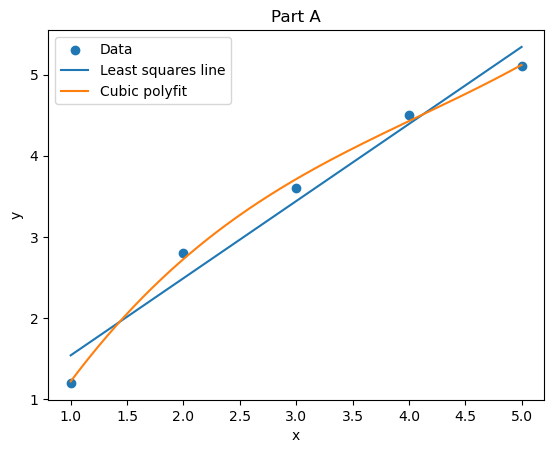


Part B
deg   MSE      R^2
  1  0.0614   0.9671
  2  0.0098   0.9947
  3  0.0048   0.9974
  4  0.0000   1.0000

Degree 1 is the most underfit here.
Degree 4 is the most overfit here because it goes through all 5 points exactly.


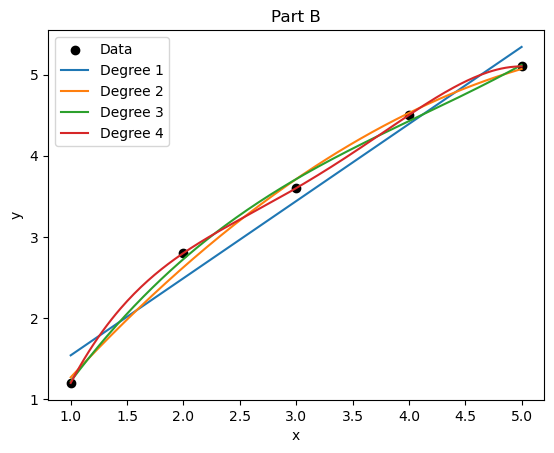


Part C
Vandermonde cubic coeffs: [ 0.0417 -0.5107  2.7476 -1.06  ]
Vandermonde -> MSE = 0.0048, R^2 = 0.9974


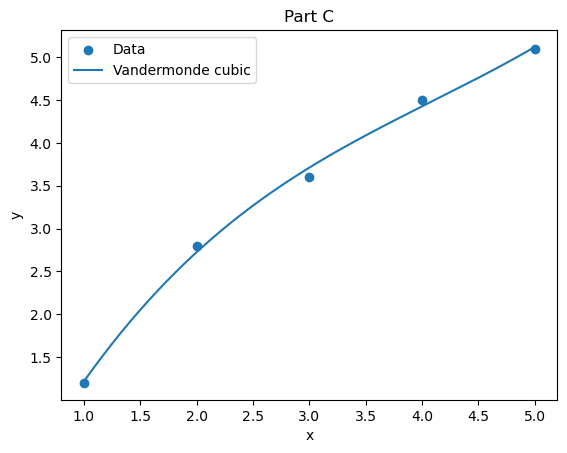

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ChatGPT was used to help organize the parts and check MSE, R^2, and Vandermonde code

x = np.array([1, 2, 3, 4, 5], dtype=float)
y = np.array([1.2, 2.8, 3.6, 4.5, 5.1], dtype=float)

def mse(y, yhat):
    return np.mean((y - yhat)**2)

def r2(y, yhat):
    return 1 - np.sum((y - yhat)**2) / np.sum((y - np.mean(y))**2)

xp = np.linspace(x.min(), x.max(), 200)

# Part A
A = np.vstack([x, np.ones(len(x))]).T
m, b = np.linalg.lstsq(A, y, rcond=None)[0]
y_line = m*x + b

p3 = np.polyfit(x, y, 3)
y_cubic = np.polyval(p3, x)

print("Part A")
print(f"Least squares line: y = {m:.4f}x + {b:.4f}")
print(f"Line   -> MSE = {mse(y, y_line):.4f}, R^2 = {r2(y, y_line):.4f}")
print(f"Cubic  -> MSE = {mse(y, y_cubic):.4f}, R^2 = {r2(y, y_cubic):.4f}")

if mse(y, y_cubic) < mse(y, y_line):
    print("Better fit: cubic polynomial")
else:
    print("Better fit: least-squares line")

plt.figure()
plt.scatter(x, y, label="Data")
plt.plot(xp, m*xp + b, label="Least squares line")
plt.plot(xp, np.polyval(p3, xp), label="Cubic polyfit")
plt.title("Part A")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

# Part B 
print("\nPart B")
print("deg   MSE      R^2")

fits = {}
for deg in range(1, 5):
    p = np.polyfit(x, y, deg)
    y_fit = np.polyval(p, x)
    fits[deg] = p
    print(f"{deg:>3}  {mse(y, y_fit):.4f}   {r2(y, y_fit):.4f}")

print("\nDegree 1 is the most underfit here.")
print("Degree 4 is the most overfit here because it goes through all 5 points exactly.")

plt.figure()
plt.scatter(x, y, color="black", label="Data")
for deg in range(1, 5):
    plt.plot(xp, np.polyval(fits[deg], xp), label=f"Degree {deg}")
plt.title("Part B")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

# Part C 
V = np.vander(x, 4)         # cubic Vandermonde matrix
c = np.linalg.lstsq(V, y, rcond=None)[0]
y_v = V @ c

print("\nPart C")
print(f"Vandermonde cubic coeffs: {np.round(c, 4)}")
print(f"Vandermonde -> MSE = {mse(y, y_v):.4f}, R^2 = {r2(y, y_v):.4f}")

plt.figure()
plt.scatter(x, y, label="Data")
plt.plot(xp, np.polyval(c, xp), label="Vandermonde cubic")
plt.title("Part C")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()